In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
data=pd.read_csv("encoded_car_data (1).csv")
data.head()

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0


In [3]:
data = pd.get_dummies(data, drop_first=True)
x=data.drop('price',axis=1)
y=data['price']

In [4]:
scaler = StandardScaler()
x = scaler.fit_transform(x)
y = scaler.fit_transform(y.values.reshape(-1, 1))

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet (alpha=1.0, l1_ratio=0.5)
}

In [7]:
result= {}
for name,model in models.items():
    pipeline = Pipeline([('poly',PolynomialFeatures(degree=2)),
    ('regressor',model)
    ])
    pipeline.fit(x_train, y_train)
    predictions = pipeline.predict(x_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    result[name] = {'MSE': mse, 'R² Score': r2}

In [8]:

print('Name: SURUTHIKA V')
print('Reg. No: 212225040441')
for model_name, metrics in result.items():
    print (f"{model_name} - Mean Squared Error: {metrics['MSE']:.2f}, R² Score: {metrics['R² Score']:.2f}")

Name: SURUTHIKA V
Reg. No: 212225040441
Ridge - Mean Squared Error: 0.26, R² Score: 0.79
Lasso - Mean Squared Error: 0.94, R² Score: 0.25
ElasticNet - Mean Squared Error: 0.63, R² Score: 0.49


In [9]:
results_df = pd.DataFrame(result).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

In [10]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

(array([0, 1, 2]),
 [Text(0, 0, 'Ridge'), Text(1, 0, 'Lasso'), Text(2, 0, 'ElasticNet')])

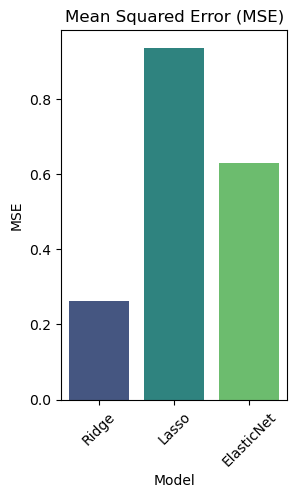

In [11]:
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks(rotation=45)

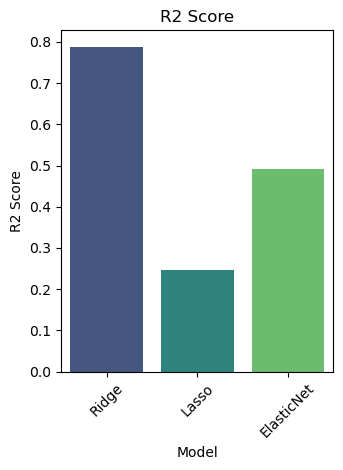

In [14]:
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis')
plt.title('R2 Score')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()